<a href="https://colab.research.google.com/github/Hiraeth-mist/ML-GTEX-Muscle-aging-biomarker-prediction/blob/main/notebooks/05_functional_enrichment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Functional Enrichment Analysis

## Objective

This notebook investigates the biological pathways and functional processes associated with age-related transcriptional changes in skeletal muscle.

Differentially expressed genes identified in Notebook 02 are subjected to Gene Ontology (GO) enrichment analysis to uncover biological processes disrupted during aging.

## Biological Questions

* Which biological processes are altered during aging?
* Do different muscle types exhibit distinct aging-associated pathways?
* Are there shared aging signatures across skeletal muscles?
* Is aging associated with changes in mitochondrial function, muscle contraction, protein homeostasis, or regenerative pathways?

## Deliverables

### Figure 11

EDL GO Biological Process Enrichment

### Figure 12

Soleus GO Biological Process Enrichment

### Figure 13

TA GO Biological Process Enrichment

### Figure 14

EDL GO Network Visualization

### Figure 15

Cross-Muscle Pathway Comparison

### Tables

* EDL Enriched GO Terms
* Soleus Enriched GO Terms
* TA Enriched GO Terms

## Expected Outcome

Identification of biological pathways and functional processes associated with skeletal muscle aging and comparison of pathway-level responses across muscle types.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
install.packages(c(
  "ggplot2",
  "dplyr"
))

if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager")

BiocManager::install(c(
  "clusterProfiler",
  "org.Mm.eg.db",
  "enrichplot",
  "DOSE"
))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Installing package(s) 'BiocVersion', 'clusterProfiler', 'org.Mm.eg.db',
  'enrichplot', 'DOSE'

also installing the dependencies ‘fontBitstreamVera’, ‘fontLiberation’, ‘XVector’, ‘Seqinfo’, ‘fontquiver’, ‘png’, ‘Biostrings’, ‘gridGraphics’, ‘gdtools’, ‘lazyeval’, ‘tweenr’, ‘polyclip’, ‘BiocGenerics’, ‘Biobase’, ‘IRanges’, ‘RSQLite’, ‘S4Vectors’, ‘KEGGREST’, ‘ggplotify’, ‘patchwork’, ‘ape’, ‘ggiraph’, ‘tidytree’, ‘treeio’, ‘ggforce’, ‘aisdk’, ‘AnnotationDbi’, ‘enrichit’, ‘GO.db’, ‘GOSemSim’, ‘gson’, ‘igraph’, ‘plyr’, ‘qvalue’, ‘yulab.utils’, ‘aplot’, ‘ggfun’, ‘ggn

In [2]:
library(clusterProfiler)
library(org.Mm.eg.db)
library(enrichplot)
library(DOSE)

library(ggplot2)
library(dplyr)



clusterProfiler v4.20.0 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

S Xu, E Hu, Y Cai, Z Xie, X Luo, L Zhan, W Tang, Q Wang, B Liu, R Wang,
W Xie, T Wu, L Xie, G Yu. Using clusterProfiler to characterize
multiomics data. Nature Protocols. 2024, 19(11):3292-3320


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter


Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames

In [5]:
res_edl_df <- read.csv(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/EDL_DE_results.csv"
)

res_sol_df <- read.csv(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/SOL_DE_results.csv"
)

res_ta_df <- read.csv(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/TA_DE_results.csv"
)

In [6]:
dir.create(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/enrichment",
recursive = TRUE,
showWarnings = FALSE
)

In [7]:
sig_edl <- subset(
  res_edl_df,
  padj < 0.05 &
  abs(log2FoldChange) > 1
)

nrow(sig_edl)

[1] 430

In [9]:
sig_sol <- subset(
  res_sol_df,
  padj < 0.05 &
  abs(log2FoldChange) > 1
)

nrow(sig_sol)

[1] 40

In [10]:
sig_ta <- subset(
  res_ta_df,
  padj < 0.05 &
  abs(log2FoldChange) > 1
)

nrow(sig_ta)

[1] 68

In [11]:
edl_entrez <- bitr(
  sig_edl$X,
  fromType = "ENSEMBL",
  toType = "ENTREZID",
  OrgDb = org.Mm.eg.db
)

head(edl_entrez)

'select()' returned 1:many mapping between keys and columns

Warning message in bitr(sig_edl$X, fromType = "ENSEMBL", toType = "ENTREZID", OrgDb = org.Mm.eg.db):
“2.79% of input gene IDs are fail to map...”


,ENSEMBL,ENTREZID
,<chr>,<chr>
1,ENSMUSG00000000435,17877
2,ENSMUSG00000000561,70465
3,ENSMUSG00000000787,13205
4,ENSMUSG00000001280,20683
5,ENSMUSG00000001333,68828
6,ENSMUSG00000001473,67951


In [12]:
sol_entrez <- bitr(
  sig_sol$X,
  fromType = "ENSEMBL",
  toType = "ENTREZID",
  OrgDb = org.Mm.eg.db
)

'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(sig_sol$X, fromType = "ENSEMBL", toType = "ENTREZID", OrgDb = org.Mm.eg.db):
“2.5% of input gene IDs are fail to map...”


In [13]:
ta_entrez <- bitr(
  sig_ta$X,
  fromType = "ENSEMBL",
  toType = "ENTREZID",
  OrgDb = org.Mm.eg.db
)

'select()' returned 1:1 mapping between keys and columns

Warning message in bitr(sig_ta$X, fromType = "ENSEMBL", toType = "ENTREZID", OrgDb = org.Mm.eg.db):
“2.94% of input gene IDs are fail to map...”


In [14]:
nrow(edl_entrez)
nrow(sol_entrez)
nrow(ta_entrez)

[1] 419

[1] 39

[1] 66

In [15]:
ego_edl <- enrichGO(
    gene = edl_entrez$ENTREZID,
    OrgDb = org.Mm.eg.db,
    keyType = "ENTREZID",
    ont = "BP",
    pAdjustMethod = "BH",
    pvalueCutoff = 0.05,
    qvalueCutoff = 0.05,
    readable = TRUE
)

head(as.data.frame(ego_edl))

,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0007517,GO:0007517,muscle organ development,21/398,381/25615,0.05511811,3.547363,6.293522,6.635817e-07,0.004262849,0.004262849,Chrnd/Foxn2/Srpk3/Actc1/Chrna1/Paxbp1/Ankrd1/Des/Zbtb18/Mtss1/Lox/Lama5/Vps54/Mbnl1/Zfhx3/Myf5/Myog/Tcap/Lmna/Kmt5b/Met,21
GO:0007178,GO:0007178,cell surface receptor protein serine/threonine kinase signaling pathway,21/398,417/25615,0.05035971,3.241116,5.796726,2.788882e-06,0.008126708,0.008126708,Map1lc3a/Ccn1/Nrep/Zfyve9/Thbs1/Lrg1/Fkbp8/Nfia/Notch2/Hfe/Atf2/Tmem100/Lox/Spry2/Lats2/Dab2/Stub1/Col1a2/Ctdspl2/Map3k1/Jak2,21
GO:0051258,GO:0051258,protein polymerization,17/398,300/25615,0.05666667,3.647027,5.793800,5.350612e-06,0.008126708,0.008126708,Tppp/Ssh1/Nin/Arl2/Togaram1/Tmod3/Ckap5/Mtss1/Ube2s/Tpgs1/Cdkn1b/Dlg1/Clasp2/Map3k1/Rictor/Met/Mapre3,17
GO:0046785,GO:0046785,microtubule polymerization,10/398,108/25615,0.09259259,5.959194,6.488239,7.333335e-06,0.008126708,0.008126708,Tppp/Nin/Arl2/Togaram1/Ckap5/Tpgs1/Cdkn1b/Clasp2/Met/Mapre3,10
GO:0045926,GO:0045926,negative regulation of growth,15/398,246/25615,0.06097561,3.924347,5.789997,7.986945e-06,0.008126708,0.008126708,Jarid2/Bst2/Rrad/Enpp1/Stk3/Sphk2/Ifrd1/Lats2/Sav1/Dab2/Sertad1/Cdkn1b/Cdkn1a/Ankrd26/Ddx3x,15
GO:0141091,GO:0141091,transforming growth factor beta receptor superfamily signaling pathway,19/398,379/25615,0.05013193,3.226455,5.486014,8.849278e-06,0.008126708,0.008126708,Ccn1/Nrep/Zfyve9/Thbs1/Lrg1/Fkbp8/Nfia/Notch2/Hfe/Atf2/Tmem100/Lox/Spry2/Lats2/Dab2/Stub1/Col1a2/Ctdspl2/Map3k1,19


In [16]:
ego_sol <- enrichGO(
    gene = sol_entrez$ENTREZID,
    OrgDb = org.Mm.eg.db,
    keyType = "ENTREZID",
    ont = "BP",
    pAdjustMethod = "BH",
    pvalueCutoff = 0.05,
    qvalueCutoff = 0.05,
    readable = TRUE
)

In [17]:
ego_ta <- enrichGO(
    gene = ta_entrez$ENTREZID,
    OrgDb = org.Mm.eg.db,
    keyType = "ENTREZID",
    ont = "BP",
    pAdjustMethod = "BH",
    pvalueCutoff = 0.05,
    qvalueCutoff = 0.05,
    readable = TRUE
)

In [18]:
nrow(as.data.frame(ego_edl))
nrow(as.data.frame(ego_sol))
nrow(as.data.frame(ego_ta))

[1] 89

[1] 13

[1] 15

In [19]:
write.csv(
    as.data.frame(ego_edl),
    "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/enrichment/EDL_GO_BP.csv",
    row.names = FALSE
)

write.csv(
    as.data.frame(ego_sol),
    "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/enrichment/Soleus_GO_BP.csv",
    row.names = FALSE
)

write.csv(
    as.data.frame(ego_ta),
    "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/enrichment/TA_GO_BP.csv",
    row.names = FALSE
)

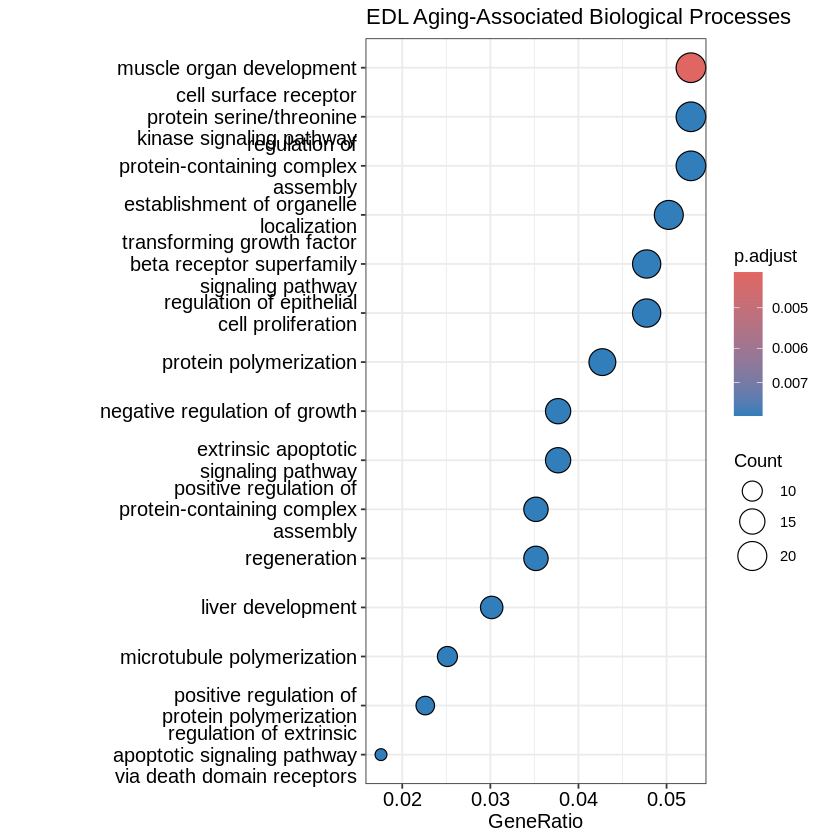

In [20]:
dotplot(
    ego_edl,
    showCategory = 15,
    title = "EDL Aging-Associated Biological Processes"
)

In [21]:
pdf(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/enrichment/EDL_GO_BP_dotplot.pdf",
width = 10,
height = 8
)

dotplot(
    ego_edl,
    showCategory = 15,
    title = "EDL Aging-Associated Biological Processes"
)

dev.off()

agg_record_1df01e92c264 
                      2

In [22]:
head(as.data.frame(ego_edl))
nrow(as.data.frame(ego_edl))
nrow(as.data.frame(ego_sol))
nrow(as.data.frame(ego_ta))

,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0007517,GO:0007517,muscle organ development,21/398,381/25615,0.05511811,3.547363,6.293522,6.635817e-07,0.004262849,0.004262849,Chrnd/Foxn2/Srpk3/Actc1/Chrna1/Paxbp1/Ankrd1/Des/Zbtb18/Mtss1/Lox/Lama5/Vps54/Mbnl1/Zfhx3/Myf5/Myog/Tcap/Lmna/Kmt5b/Met,21
GO:0007178,GO:0007178,cell surface receptor protein serine/threonine kinase signaling pathway,21/398,417/25615,0.05035971,3.241116,5.796726,2.788882e-06,0.008126708,0.008126708,Map1lc3a/Ccn1/Nrep/Zfyve9/Thbs1/Lrg1/Fkbp8/Nfia/Notch2/Hfe/Atf2/Tmem100/Lox/Spry2/Lats2/Dab2/Stub1/Col1a2/Ctdspl2/Map3k1/Jak2,21
GO:0051258,GO:0051258,protein polymerization,17/398,300/25615,0.05666667,3.647027,5.793800,5.350612e-06,0.008126708,0.008126708,Tppp/Ssh1/Nin/Arl2/Togaram1/Tmod3/Ckap5/Mtss1/Ube2s/Tpgs1/Cdkn1b/Dlg1/Clasp2/Map3k1/Rictor/Met/Mapre3,17
GO:0046785,GO:0046785,microtubule polymerization,10/398,108/25615,0.09259259,5.959194,6.488239,7.333335e-06,0.008126708,0.008126708,Tppp/Nin/Arl2/Togaram1/Ckap5/Tpgs1/Cdkn1b/Clasp2/Met/Mapre3,10
GO:0045926,GO:0045926,negative regulation of growth,15/398,246/25615,0.06097561,3.924347,5.789997,7.986945e-06,0.008126708,0.008126708,Jarid2/Bst2/Rrad/Enpp1/Stk3/Sphk2/Ifrd1/Lats2/Sav1/Dab2/Sertad1/Cdkn1b/Cdkn1a/Ankrd26/Ddx3x,15
GO:0141091,GO:0141091,transforming growth factor beta receptor superfamily signaling pathway,19/398,379/25615,0.05013193,3.226455,5.486014,8.849278e-06,0.008126708,0.008126708,Ccn1/Nrep/Zfyve9/Thbs1/Lrg1/Fkbp8/Nfia/Notch2/Hfe/Atf2/Tmem100/Lox/Spry2/Lats2/Dab2/Stub1/Col1a2/Ctdspl2/Map3k1,19


[1] 89

[1] 13

[1] 15

In [23]:
pdf(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/enrichment/EDL_GO_BP_dotplot.pdf",
width = 10,
height = 8
)

dotplot(
    ego_edl,
    showCategory = 15,
    title = "EDL Aging-Associated Biological Processes"
)

dev.off()

agg_record_1df06e3b4530 
                      2

In [24]:
pdf(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/enrichment/Soleus_GO_BP_dotplot.pdf",
width = 10,
height = 8
)

dotplot(
    ego_sol,
    showCategory = 15,
    title = "Soleus Aging-Associated Biological Processes"
)

dev.off()

agg_record_1df0159d13e0 
                      2

In [25]:
pdf(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/enrichment/TA_GO_BP_dotplot.pdf",
width = 10,
height = 8
)

dotplot(
    ego_ta,
    showCategory = 15,
    title = "TA Aging-Associated Biological Processes"
)

dev.off()

agg_record_1df0309f6d55 
                      2

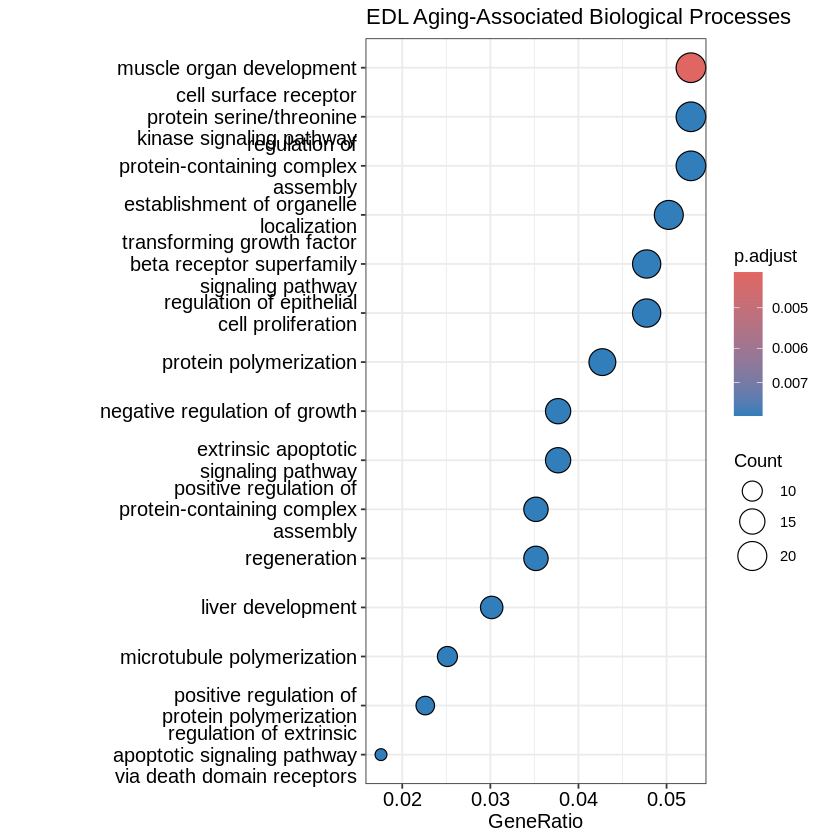

In [26]:
dotplot(
    ego_edl,
    showCategory = 15,
    title = "EDL Aging-Associated Biological Processes"
)

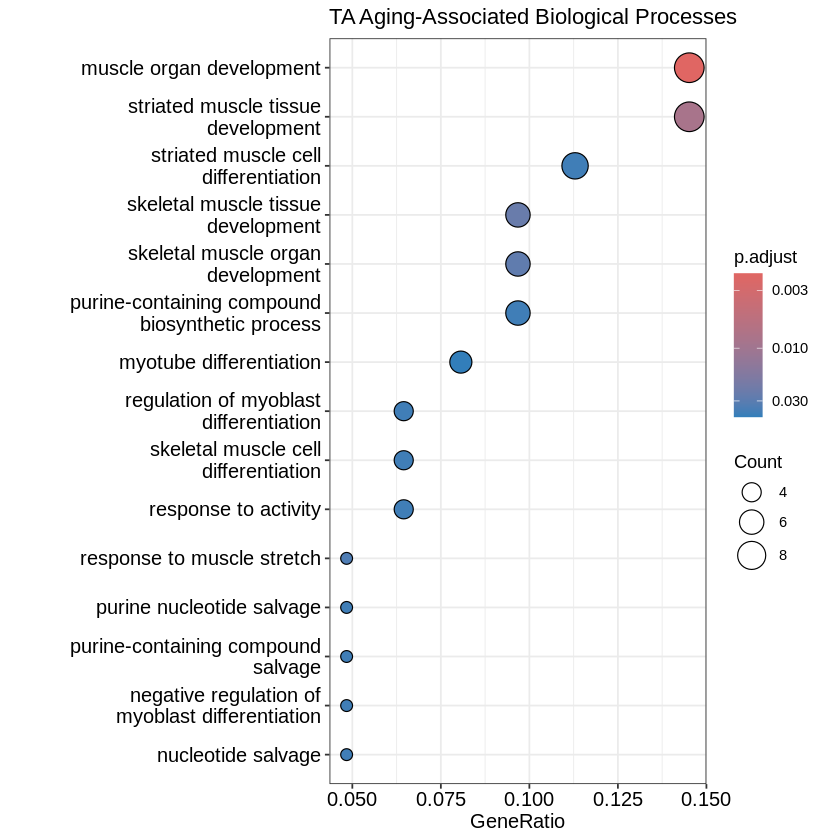

In [27]:
dotplot(
    ego_ta,
    showCategory = 15,
    title = "TA Aging-Associated Biological Processes"
)

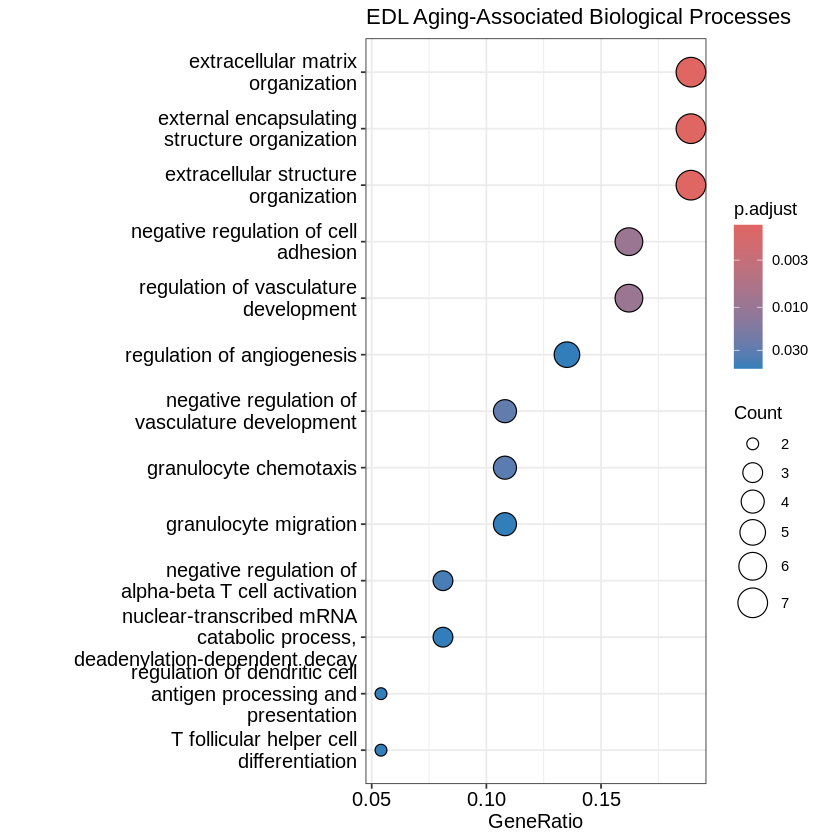

In [28]:
dotplot(
    ego_sol,
    showCategory = 15,
    title = "EDL Aging-Associated Biological Processes"
)

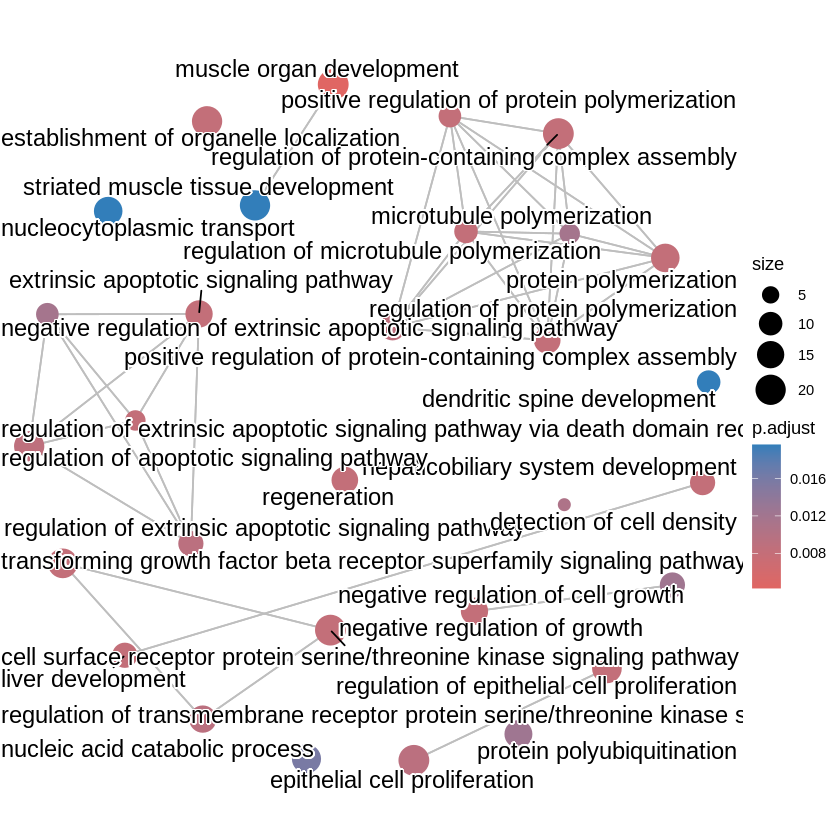

In [29]:
emapplot(pairwise_termsim(ego_edl))

In [30]:
head(as.data.frame(ego_edl)[,c("Description","p.adjust")],10)

head(as.data.frame(ego_sol)[,c("Description","p.adjust")],10)

head(as.data.frame(ego_ta)[,c("Description","p.adjust")],10)

,Description,p.adjust
,<chr>,<dbl>
GO:0007517,muscle organ development,0.004262849
GO:0007178,cell surface receptor protein serine/threonine kinase signaling pathway,0.008126708
GO:0051258,protein polymerization,0.008126708
GO:0046785,microtubule polymerization,0.008126708
GO:0045926,negative regulation of growth,0.008126708
GO:0141091,transforming growth factor beta receptor superfamily signaling pathway,0.008126708
GO:0051656,establishment of organelle localization,0.008126708
GO:0097191,extrinsic apoptotic signaling pathway,0.008126708
GO:1902041,regulation of extrinsic apoptotic signaling pathway via death domain receptors,0.008126708


,Description,p.adjust
,<chr>,<dbl>
GO:0030198,extracellular matrix organization,0.001225128
GO:0045229,external encapsulating structure organization,0.001225128
GO:0043062,extracellular structure organization,0.001225128
GO:0007162,negative regulation of cell adhesion,0.009319289
GO:1901342,regulation of vasculature development,0.009319289
GO:1901343,negative regulation of vasculature development,0.028740253
GO:0071621,granulocyte chemotaxis,0.031729527
GO:0046636,negative regulation of alpha-beta T cell activation,0.039206255
GO:0000288,"nuclear-transcribed mRNA catabolic process, deadenylation-dependent decay",0.047808797


,Description,p.adjust
,<chr>,<dbl>
GO:0007517,muscle organ development,0.002108796
GO:0014706,striated muscle tissue development,0.008450045
GO:0007519,skeletal muscle tissue development,0.025385057
GO:0060538,skeletal muscle organ development,0.028139650
GO:0035994,response to muscle stretch,0.033863303
GO:0032261,purine nucleotide salvage,0.038274759
GO:0043101,purine-containing compound salvage,0.038274759
GO:0072522,purine-containing compound biosynthetic process,0.038274759
GO:0051146,striated muscle cell differentiation,0.038274759


In [31]:
pdf(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/enrichment/EDL_emapplot.pdf",
width = 12,
height = 10
)

emapplot(pairwise_termsim(ego_edl))

dev.off()

agg_record_1df09d0268 
                    2